In [ ]:
import cv2
from google.colab.patches import cv2_imshow

def detect_cars(img, show_result=False, max_display_dim=600):
    """
    Detects cars in the image using Haar Cascade and optionally displays the result.
    """
    if img is None:
        return None, 0

    # Load Haar cascade from local XML file
    cascade_path = '/content/cars.xml'
    car_cascade = cv2.CascadeClassifier(cascade_path)

    if car_cascade.empty():
        raise ValueError(f"Failed to load Haar cascade from path: {cascade_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    cars = car_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(30, 30),
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    for (x, y, w, h) in cars:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    if show_result:
        height, width = img.shape[:2]
        scale = min(max_display_dim / height, max_display_dim / width)
        if scale < 1.0:
            resized = cv2.resize(img, (int(width * scale), int(height * scale)), interpolation=cv2.INTER_AREA)
            cv2_imshow(resized)
        else:
            cv2_imshow(img)

    return img, len(cars)

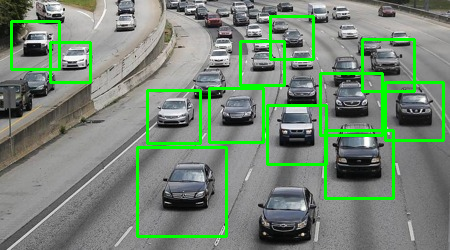

Number of cars detected: 12


In [ ]:
img = cv2.imread('/content/car_traffic.jpeg')  # Or a traffic image with cars
result_img, num_cars = detect_cars(img, show_result=True)
print(f"Number of cars detected: {num_cars}")

In [ ]:
import cv2
import os
from sklearn.metrics import classification_report

def detect_car_classification(img_path, classifier):
    img = cv2.imread(img_path)
    if img is None:
        return 0

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)

    cars = classifier.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(30, 30),
        flags=cv2.CASCADE_SCALE_IMAGE
    )
    return 1 if len(cars) > 0 else 0

# Load Haar cascade for car detection
car_cascade = cv2.CascadeClassifier('/content/cars.xml')

# Ground truth and prediction lists
y_true = []
y_pred = []

# Paths
car_folder = "/content/test_data/p"       # Positive samples
non_car_folder = "/content/test_data/n"  # Negative samples

# Positive samples (should detect cars)
for fname in os.listdir(car_folder):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        path = os.path.join(car_folder, fname)
        y_true.append(1)
        y_pred.append(detect_car_classification(path, car_cascade))

# Negative samples (should NOT detect cars)
for fname in os.listdir(non_car_folder):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        path = os.path.join(non_car_folder, fname)
        y_true.append(0)
        y_pred.append(detect_car_classification(path, car_cascade))

# classification report
report = classification_report(y_true, y_pred, target_names=["No Car", "Car"])
print(report)

              precision    recall  f1-score   support

      No Car       0.84      0.73      0.78        22
         Car       0.62      0.77      0.69        13

    accuracy                           0.74        35
   macro avg       0.73      0.75      0.74        35
weighted avg       0.76      0.74      0.75        35

